# 01.2 Data Exploration – Chicago Weather 2024–2026

Hourly weather data for Chicago from 2024-01-01 through 2026-05-31. The full dataset is used for completeness checks, time-series plots, and extreme values. Calendar-month and seasonal comparisons account explicitly for incomplete 2026.

**Source:** `data/chicago_weather_2024_2026_hourly.csv`, retrieved from the [Open-Meteo Archive API](https://archive-api.open-meteo.com/v1/archive).

| Column | Description | Unit |
|---|---|---|
| `datetime` | Hourly timestamp | – |
| `temperature_2m` | Temperature 2 m above ground | °C |
| `apparent_temperature` | Apparent temperature | °C |
| `precipitation` | Precipitation | mm |
| `snowfall` | Snowfall | cm |
| `wind_speed_10m` | Wind speed 10 m above ground | km/h |
| `cloud_cover` | Cloud cover | % |
| `weather_code` | WMO weather code | – |
| `weather_description` | Weather description | – |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 4)

## 1. Load Data

The data are loaded with an hourly `DatetimeIndex` so temporal completeness, resampling, and aggregation can be evaluated consistently.

In [2]:
df = pd.read_csv(
    '../../data/chicago_weather_2024_2026_hourly.csv',
    parse_dates=['datetime']
)
df = df.set_index('datetime').sort_index()
print(f'Period: {df.index.min()}  ->  {df.index.max()}')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head()

Period: 2024-01-01 00:00:00  ->  2026-05-31 23:00:00
Rows: 21,168  |  Columns: 8


,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,weather_code,weather_description
datetime,,,,,,,,
2024-01-01 00:00:00,0.6,-6.3,0.1,0.07,18.9,100,71,Slight snowfall
2024-01-01 01:00:00,0.4,-6.5,0.1,0.07,18.9,100,71,Slight snowfall
2024-01-01 02:00:00,0.5,-6.2,0.1,0.07,18.7,100,71,Slight snowfall
2024-01-01 03:00:00,0.8,-5.6,0.1,0.07,17.3,100,71,Slight snowfall
2024-01-01 04:00:00,0.6,-5.5,0.0,0.00,15.8,100,3,Overcast


## 2. Basic Overview

Data types and descriptive statistics provide an initial plausibility check across all 21,168 hourly observations.

In [3]:
df.dtypes

temperature_2m          float64
apparent_temperature    float64
precipitation           float64
snowfall                float64
wind_speed_10m          float64
cloud_cover               int64
weather_code              int64
weather_description         str
dtype: object

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature_2m,21168.0,10.24,11.13,-24.9,2.0,10.5,19.4,36.20
apparent_temperature,21168.0,7.76,13.50,-32.1,-2.6,7.5,18.9,41.10
precipitation,21168.0,0.11,0.57,0.0,0.0,0.0,0.0,19.80
snowfall,21168.0,0.01,0.07,0.0,0.0,0.0,0.0,3.29
wind_speed_10m,21168.0,8.84,4.34,0.0,5.7,8.3,11.4,28.00
cloud_cover,21168.0,58.50,43.77,0.0,5.0,82.0,100.0,100.00
weather_code,21168.0,9.19,19.57,0.0,0.0,3.0,3.0,75.00


## 3. Missing Values and Temporal Completeness

Both missing field values and missing hourly timestamps are checked across the complete observed period, not only within a single calendar year.

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

expected_hours = pd.date_range(df.index.min().floor('h'), df.index.max().floor('h'), freq='h')
missing_ts = expected_hours.difference(df.index)
print(f'Expected hours: {len(expected_hours):,}')
print(f'Missing timestamps: {len(missing_ts):,}')

Missing values per column:
temperature_2m          0
apparent_temperature    0
precipitation           0
snowfall                0
wind_speed_10m          0
cloud_cover             0
weather_code            0
weather_description     0
dtype: int64
Expected hours: 21,168
Missing timestamps: 0


## 4. Temperature Across the Observation Period

Hourly air and apparent temperature reveal seasonal cycles and short-lived extremes across January 2024 to May 2026. The partial 2026 series is shown as observed and is not extrapolated.

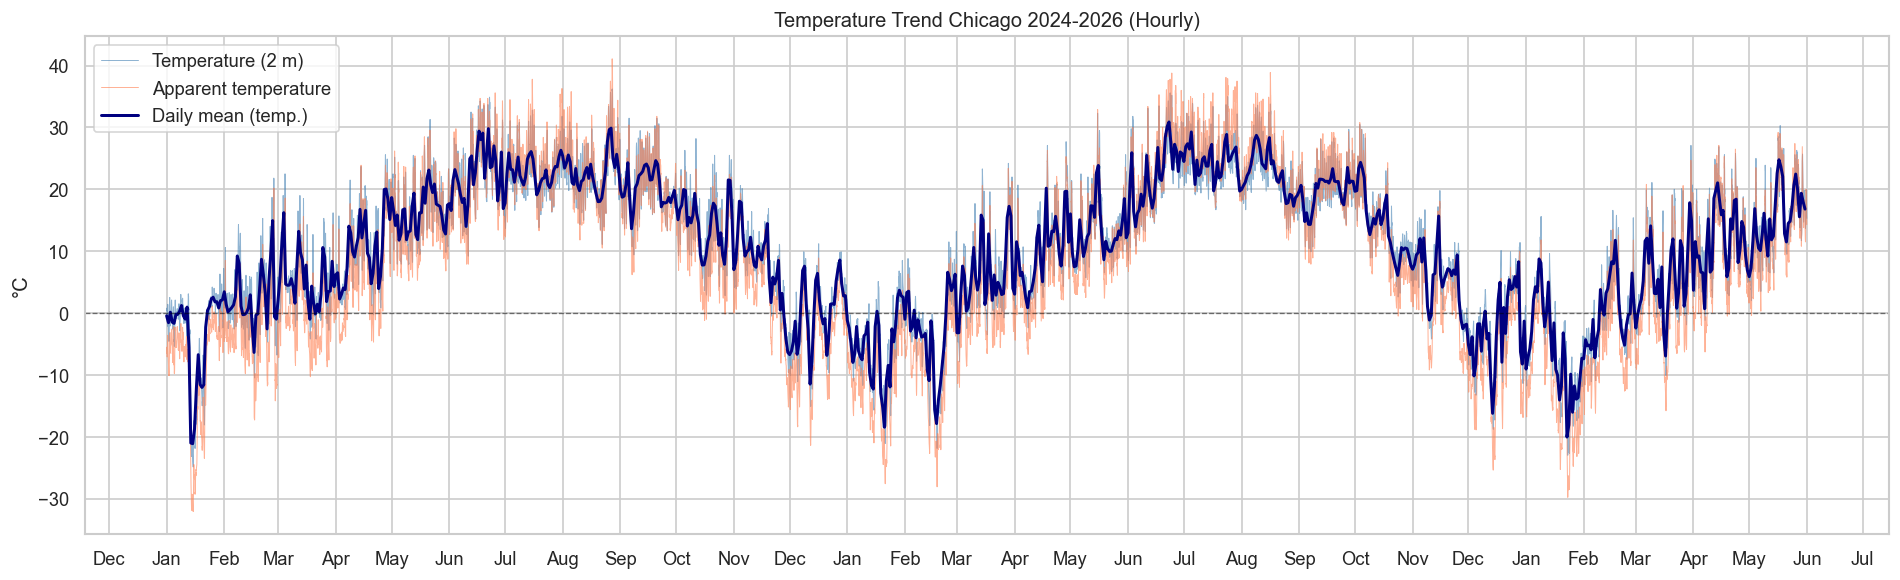

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['temperature_2m'], lw=0.6, alpha=0.6, color='steelblue', label='Temperature (2 m)')
ax.plot(df.index, df['apparent_temperature'], lw=0.6, alpha=0.6, color='coral', label='Apparent temperature')
daily_mean = df['temperature_2m'].resample('D').mean()
ax.plot(daily_mean.index, daily_mean, lw=1.8, color='navy', label='Daily mean (temp.)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Temperature Trend Chicago 2024-2026 (Hourly)')
ax.set_ylabel('°C')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Calendar-Month Patterns

Temperature statistics use all hourly observations. Precipitation and snowfall are first summed within each year-month and then averaged by calendar month. This prevents January–May from appearing wetter merely because they are observed in three years while June–December are observed in two.

In [7]:
df['month'] = df.index.month
df['month_name'] = df.index.strftime('%b')

monthly_temperature = df.groupby('month').agg(
    temp_mean=('temperature_2m', 'mean'),
    temp_min=('temperature_2m', 'min'),
    temp_max=('temperature_2m', 'max'),
    wind_mean=('wind_speed_10m', 'mean'),
)
year_month_totals = df.resample('MS').agg(
    precip_mean_month=('precipitation', 'sum'),
    snow_mean_month=('snowfall', 'sum'),
)
monthly_hydrology = year_month_totals.groupby(year_month_totals.index.month).mean()
monthly = monthly_temperature.join(monthly_hydrology).round(2)
monthly.index = pd.to_datetime(monthly.index, format='%m').strftime('%b')
monthly

,temp_mean,temp_min,temp_max,wind_mean,precip_mean_month,snow_mean_month
month,,,,,,
Jan,-4.98,-24.9,15.6,9.99,73.33,20.00
Feb,-0.18,-21.9,21.8,8.86,18.97,7.00
Mar,5.70,-10.1,27.1,10.18,102.50,8.84
Apr,10.55,-2.4,27.7,9.95,112.70,1.77
May,14.99,2.0,32.3,8.12,67.70,0.00
Jun,22.28,8.5,35.6,8.96,98.35,0.00
Jul,23.62,13.7,35.0,6.88,137.00,0.00
Aug,22.75,11.1,36.2,7.32,56.30,0.00
Sep,20.11,9.4,31.5,7.42,52.75,0.00


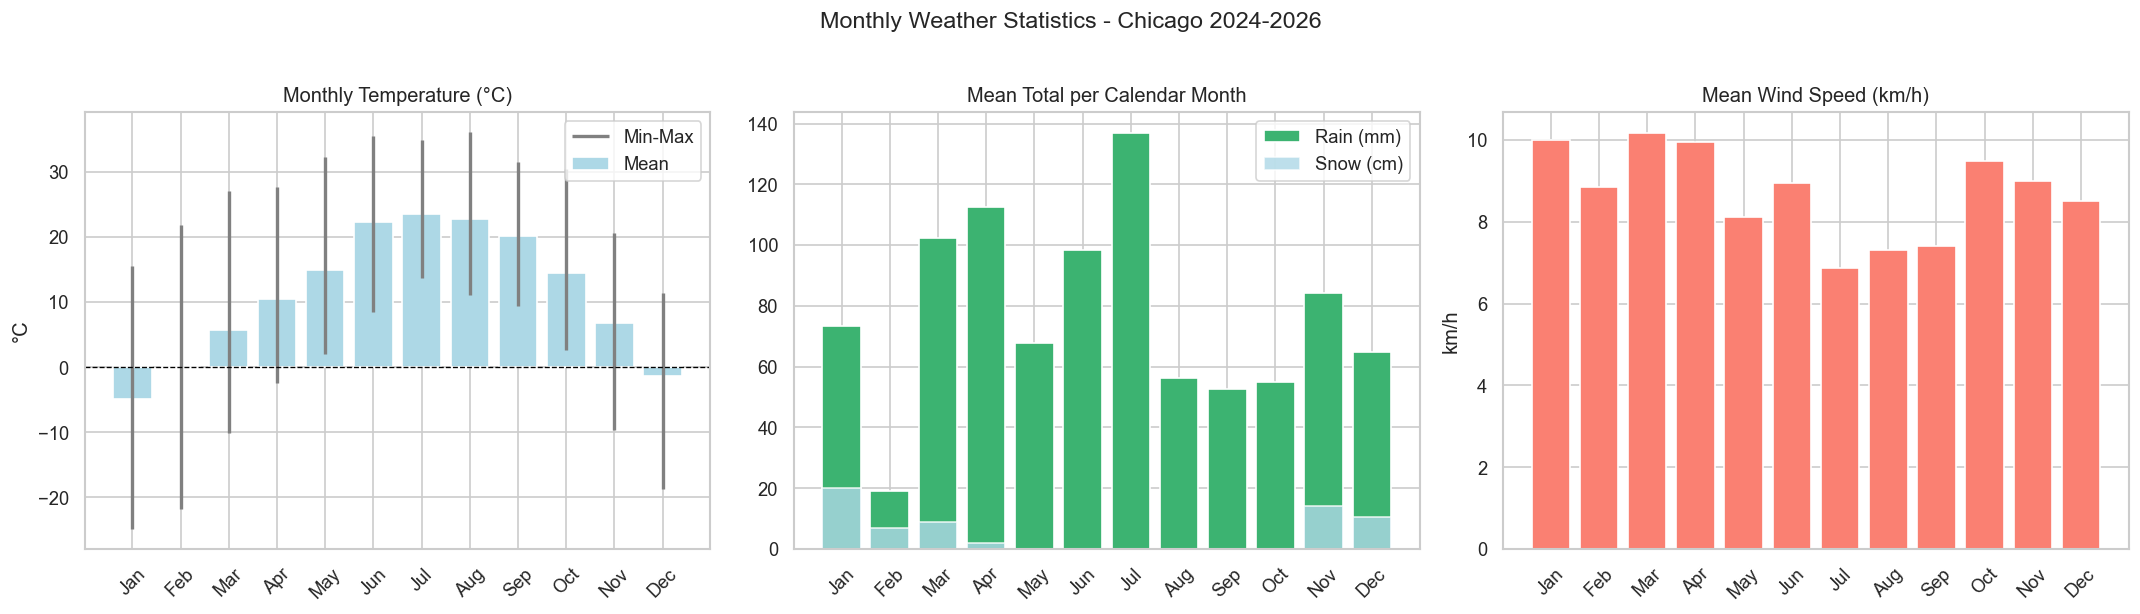

In [8]:
months = list(monthly.index)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(months, monthly['temp_mean'], color='lightblue', label='Mean')
axes[0].vlines(months, monthly['temp_min'], monthly['temp_max'], color='gray', lw=2, label='Min-Max')
axes[0].axhline(0, ls='--', color='black', lw=0.8)
axes[0].set_title('Monthly Temperature (°C)')
axes[0].set_ylabel('°C')
axes[0].legend()

axes[1].bar(months, monthly['precip_mean_month'], color='mediumseagreen', label='Rain (mm)')
axes[1].bar(months, monthly['snow_mean_month'], bottom=0, color='lightblue', alpha=0.8, label='Snow (cm)')
axes[1].set_title('Mean Total per Calendar Month')
axes[1].legend()

axes[2].bar(months, monthly['wind_mean'], color='salmon')
axes[2].set_title('Mean Wind Speed (km/h)')
axes[2].set_ylabel('km/h')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Monthly Weather Statistics - Chicago 2024-2026', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Seasonal Analysis

Seasonal distributions use the two complete calendar years, 2024 and 2025. Excluding partial 2026 prevents winter and spring from receiving an additional year of observations relative to summer and autumn. Full-period data remain in use for time-series and extreme-value analyses.

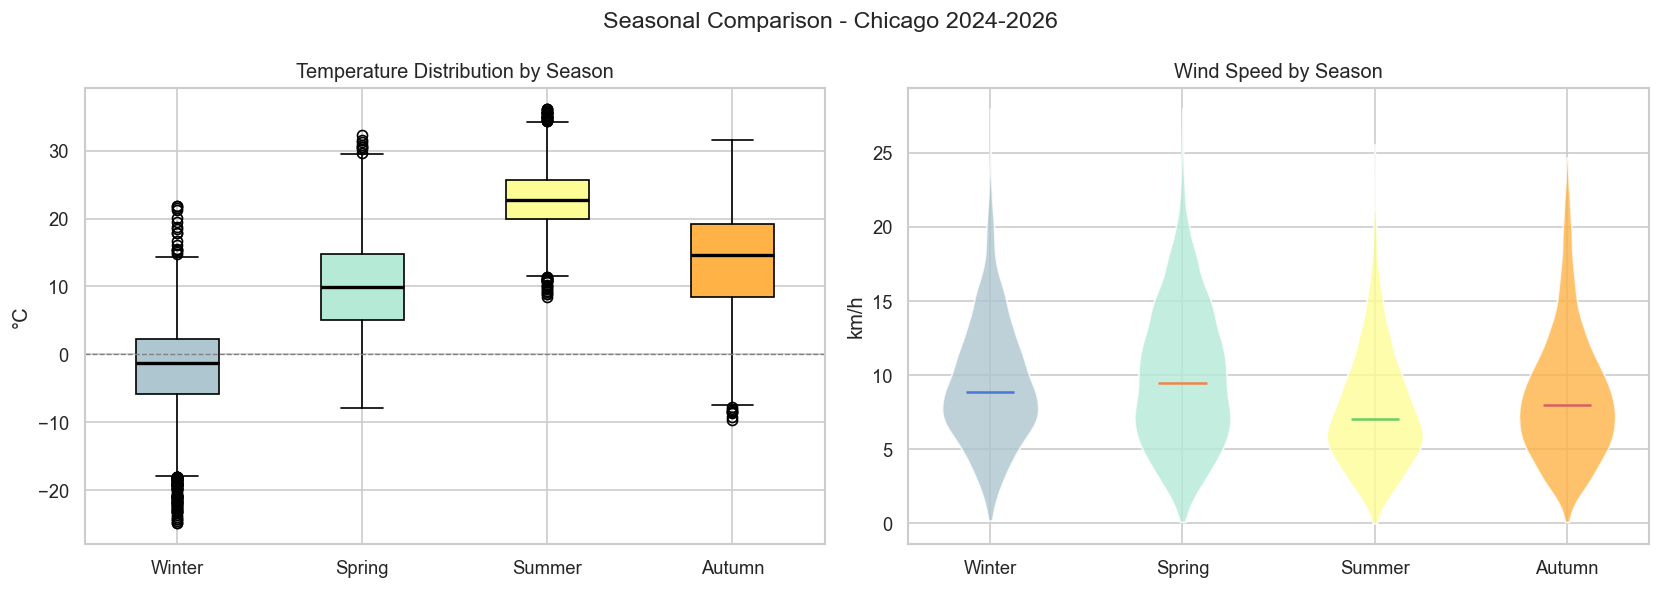

In [9]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['season'] = df['month'].map(season_map)
seasonal_df = df[df.index.year.isin([2024, 2025])].copy()
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_data = [seasonal_df.loc[seasonal_df['season'] == s, 'temperature_2m'].values for s in season_order]
bp = axes[0].boxplot(season_data, tick_labels=season_order, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
colors = ['#aec6cf', '#b5ead7', '#fdfd96', '#ffb347']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].axhline(0, ls='--', color='gray', lw=0.8)
axes[0].set_title('Temperature Distribution by Season')
axes[0].set_ylabel('°C')

for i, s in enumerate(season_order, 1):
    vals = seasonal_df.loc[seasonal_df['season'] == s, 'wind_speed_10m'].values
    parts = axes[1].violinplot(vals, positions=[i], showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i-1])
        pc.set_alpha(0.8)
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(season_order)
axes[1].set_title('Wind Speed by Season')
axes[1].set_ylabel('km/h')

plt.suptitle('Seasonal Comparison - Chicago 2024-2026', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Intraday Temperature Pattern

Mean hourly profiles show how the daily temperature cycle differs by season. This balanced seasonal comparison also uses the complete years 2024 and 2025.

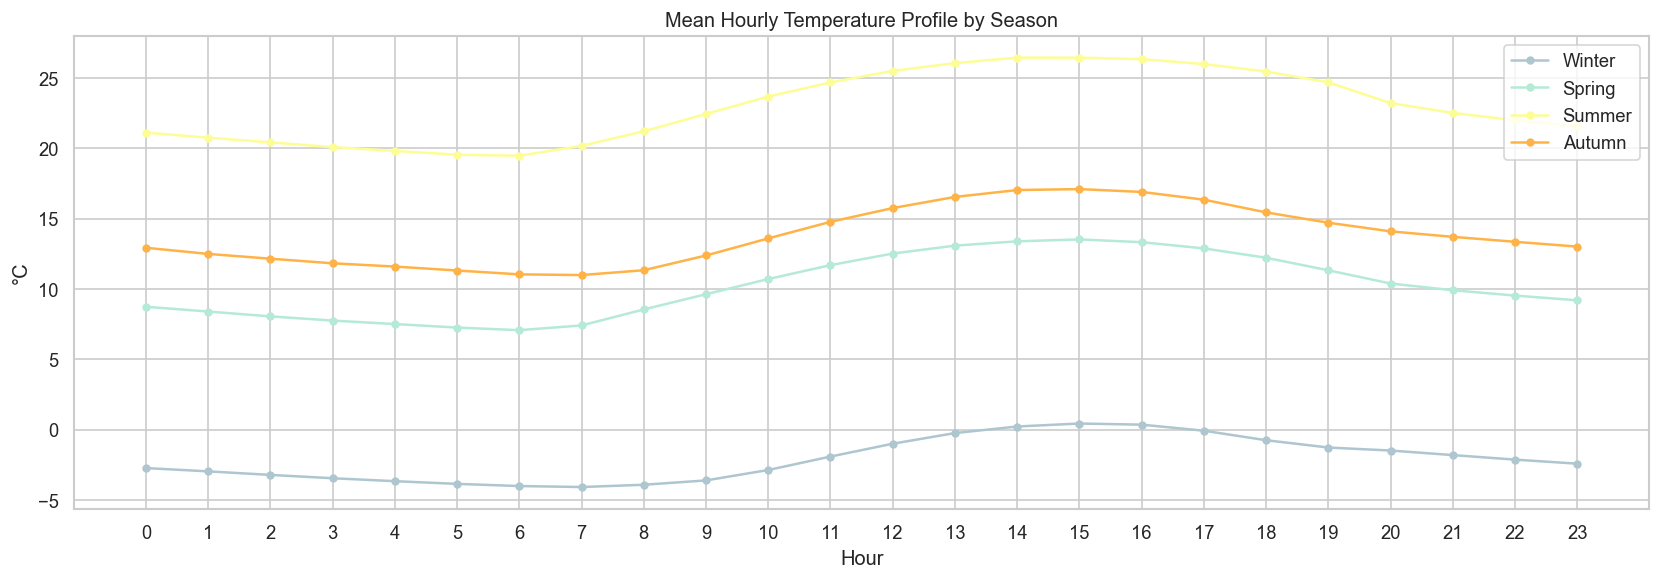

In [10]:
df['hour'] = df.index.hour
seasonal_df['hour'] = seasonal_df.index.hour
hourly_profile = seasonal_df.groupby(['season', 'hour'])['temperature_2m'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 5))
palette = {'Winter': '#aec6cf', 'Spring': '#b5ead7', 'Summer': '#fdfd96', 'Autumn': '#ffb347'}
for season in season_order:
    ax.plot(hourly_profile.index, hourly_profile[season], marker='o', ms=4, label=season,
            color=palette[season])
ax.set_title('Mean Hourly Temperature Profile by Season')
ax.set_xlabel('Hour')
ax.set_ylabel('°C')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Precipitation and Snowfall

Hourly values are aggregated to daily totals. Totals and event-day counts are reported by calendar year; 2026 is explicitly a partial January–May period.

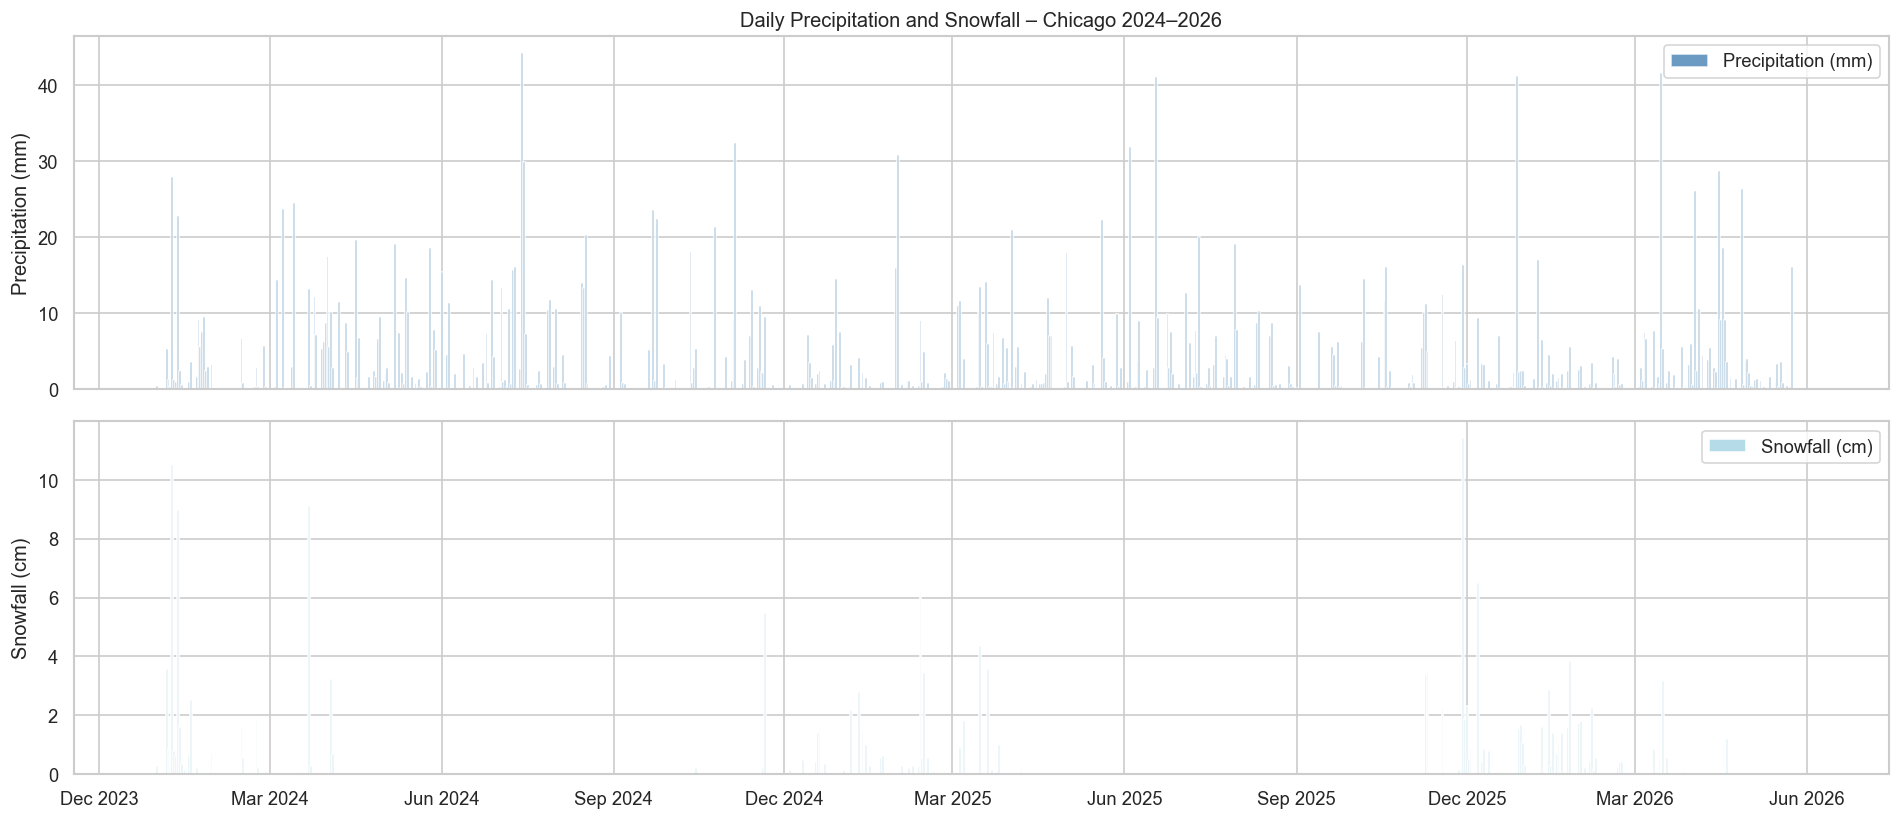

,observed_days,precipitation_mm,snowfall_cm,rain_days,snow_days
year,,,,,
2024,366,1030.8,59.8,162,35
2025,365,832.3,72.4,166,48
2026,151,359.6,29.9,79,31


In [11]:
daily = df.resample('D').agg(
    precip=('precipitation', 'sum'),
    snow=('snowfall', 'sum'),
    temp=('temperature_2m', 'mean')
)
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
axes[0].bar(daily.index, daily['precip'], width=1, color='steelblue', alpha=0.8, label='Precipitation (mm)')
axes[0].set_ylabel('Precipitation (mm)')
axes[0].set_title('Daily Precipitation and Snowfall – Chicago 2024–2026')
axes[0].legend()
axes[1].bar(daily.index, daily['snow'], width=1, color='lightblue', alpha=0.9, label='Snowfall (cm)')
axes[1].set_ylabel('Snowfall (cm)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].legend()
plt.tight_layout(); plt.show()

yearly_weather = pd.DataFrame({
    'observed_days': daily.groupby(daily.index.year).size(),
    'precipitation_mm': daily['precip'].groupby(daily.index.year).sum(),
    'snowfall_cm': daily['snow'].groupby(daily.index.year).sum(),
    'rain_days': (daily['precip'] > 0.1).groupby(daily.index.year).sum(),
    'snow_days': (daily['snow'] > 0).groupby(daily.index.year).sum(),
}).round(1)
yearly_weather.index.name = 'year'
yearly_weather

## 9. Weather-Code Distribution

Weather descriptions summarize conditions across all observed hours. They represent modeled Open-Meteo classifications rather than station-level manual observations.

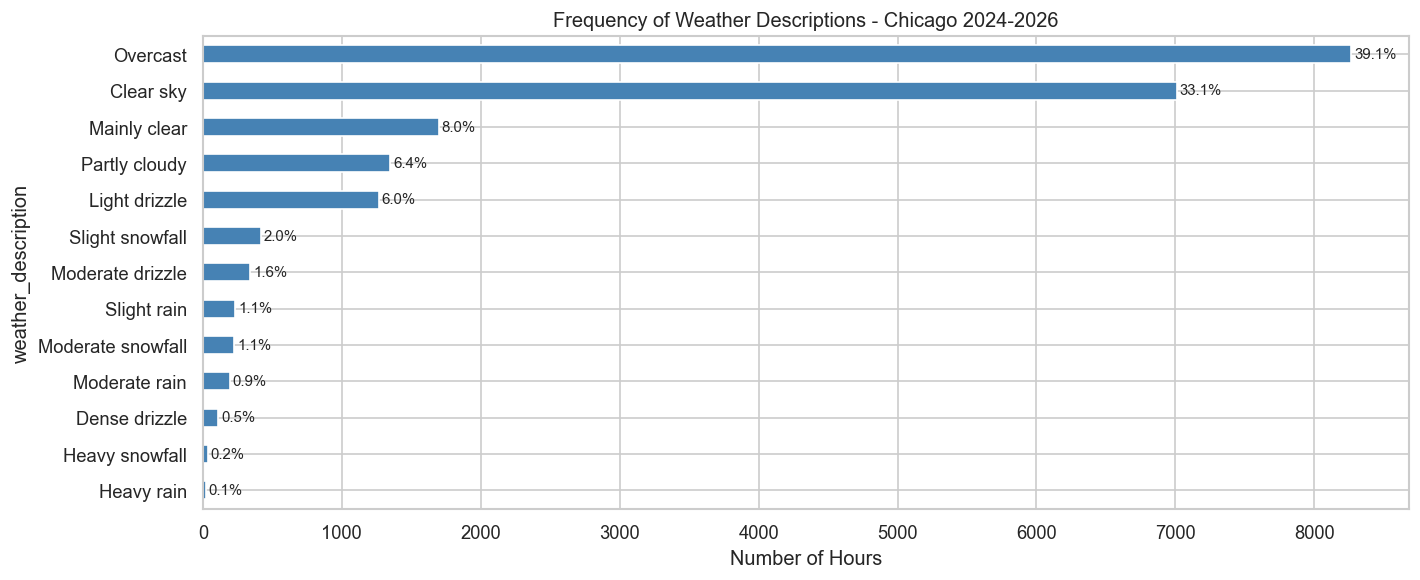

In [12]:
desc_counts = df['weather_description'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
desc_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Frequency of Weather Descriptions - Chicago 2024-2026')
ax.set_xlabel('Number of Hours')
ax.invert_yaxis()
for i, v in enumerate(desc_counts):
    pct = v / len(df) * 100
    ax.text(v + 20, i, f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Correlation Matrix

Pairwise correlations describe linear relationships among weather variables. They are descriptive and should not be interpreted as causal effects.

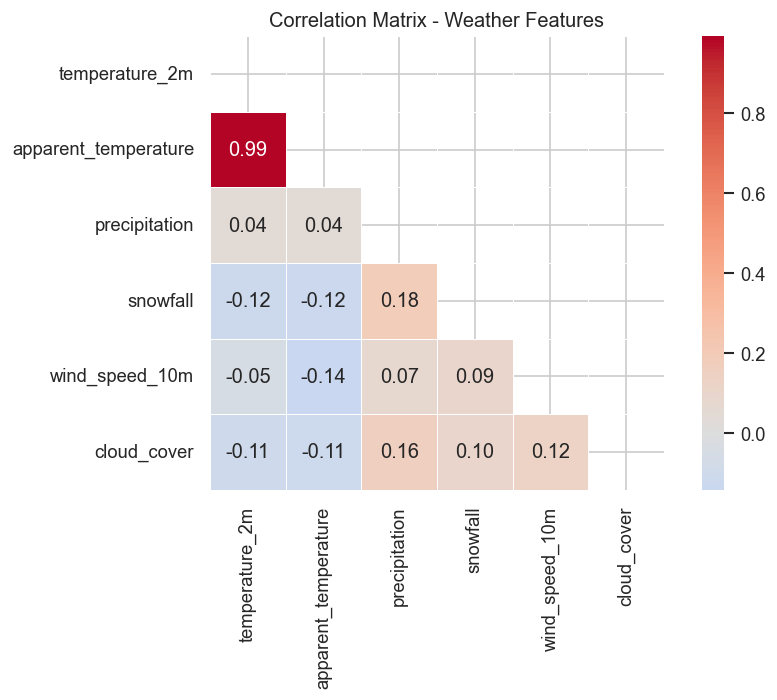

In [13]:
numeric_cols = ['temperature_2m', 'apparent_temperature', 'precipitation',
                'snowfall', 'wind_speed_10m', 'cloud_cover']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Weather Features')
plt.tight_layout()
plt.show()

## 11. Extreme Values and Key Figures

Extreme events and overall averages use the complete January 2024 to May 2026 period. The overall mean is not labeled an annual average because the period contains two full years and five additional months.

In [14]:
print('=== Temperature Extremes ===')
print(f"Highest temperature: {df['temperature_2m'].max():.1f} °C  on {df['temperature_2m'].idxmax()}")
print(f"Lowest temperature:  {df['temperature_2m'].min():.1f} °C  on {df['temperature_2m'].idxmin()}")
print(f"Overall-period mean:      {df['temperature_2m'].mean():.1f} °C")

print('=== Apparent Temperature Extremes ===')
print(f"Lowest apparent temp.: {df['apparent_temperature'].min():.1f} °C  on {df['apparent_temperature'].idxmin()}")

print('=== Strongest Precipitation Event ===')
print(f"Max. hourly rain:       {df['precipitation'].max():.1f} mm  on {df['precipitation'].idxmax()}")

print('=== Wind ===')
print(f"Highest wind speed: {df['wind_speed_10m'].max():.1f} km/h  on {df['wind_speed_10m'].idxmax()}")
print(f"Mean wind speed: {df['wind_speed_10m'].mean():.1f} km/h")

print('=== Cloud Cover ===')
print(f"Share of fully overcast sky (100%): {(df['cloud_cover']==100).mean()*100:.1f}%")
print(f"Share of clear sky (<=10%):                  {(df['cloud_cover']<=10).mean()*100:.1f}%")

=== Temperature Extremes ===
Highest temperature: 36.2 °C  on 2024-08-27 14:00:00
Lowest temperature:  -24.9 °C  on 2024-01-15 07:00:00
Overall-period mean:      10.2 °C
=== Apparent Temperature Extremes ===
Lowest apparent temp.: -32.1 °C  on 2024-01-15 07:00:00
=== Strongest Precipitation Event ===
Max. hourly rain:       19.8 mm  on 2024-07-14 23:00:00
=== Wind ===
Highest wind speed: 28.0 km/h  on 2024-01-12 09:00:00
Mean wind speed: 8.8 km/h
=== Cloud Cover ===
Share of fully overcast sky (100%): 37.9%
Share of clear sky (<=10%):                  29.1%


## 12. Temperature Heatmap by Month and Hour

The heatmap combines calendar-month and intraday patterns. June–December are based on 2024–2025, while January–May additionally include 2026.

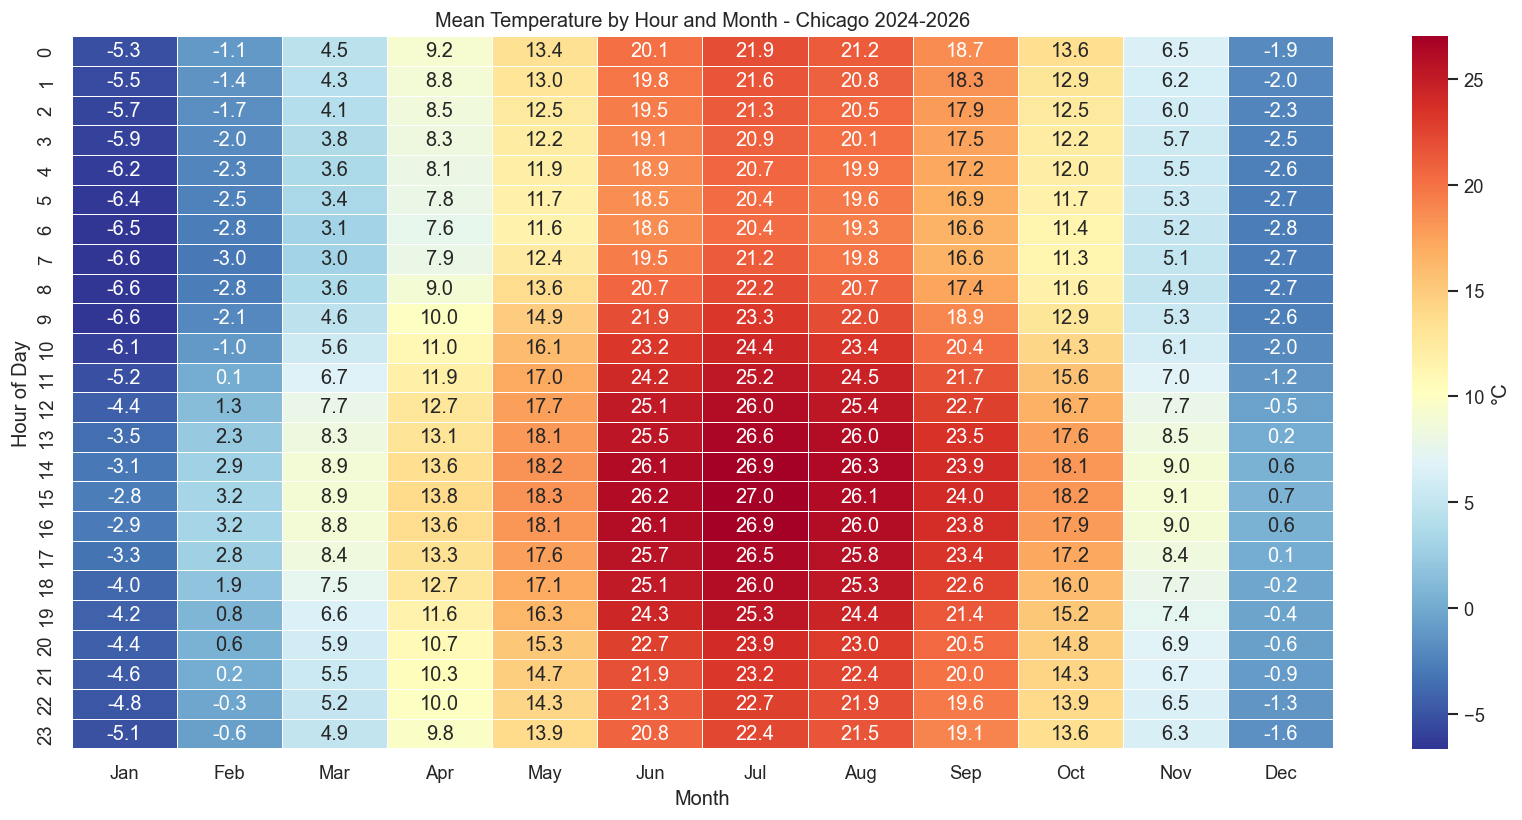

In [15]:
pivot = df.pivot_table(values='temperature_2m', index='hour', columns='month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap='RdYlBu_r', annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': '°C'}, ax=ax)
ax.set_title('Mean Temperature by Hour and Month - Chicago 2024-2026')
ax.set_xlabel('Month')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()

## 13. Summary

| Metric | Result |
|---|---|
| Coverage | 21,168 consecutive hourly observations |
| Period | 2024-01-01 to 2026-05-31 |
| Missing values / timestamps | 0 / 0 |
| Overall mean temperature | 10.2 °C |
| Observed temperature range | −24.9 °C to 36.2 °C |
| Coldest calendar month | January (mean approximately −5.0 °C) |
| Warmest calendar month | July (mean approximately 23.6 °C) |
| Strongest hourly precipitation | 19.8 mm on 2024-07-14 at 23:00 |
| Dominant weather descriptions | Overcast, followed by clear sky |

**Key results**

- Chicago weather exhibits a pronounced seasonal temperature pattern and a smaller but consistent intraday temperature cycle.
- Apparent temperature is almost perfectly correlated with air temperature ($r \approx 0.99$), but can be substantially lower during cold and windy periods; the observed minimum is −32.1 °C.
- Precipitation occurs throughout the period, whereas snowfall is concentrated in colder months. Annual totals are reported separately because 2026 contains only January through May.
- Cloud cover has only a weak negative correlation with temperature ($r \approx -0.11$). Overcast conditions account for approximately 37.9% of observed hours, while clear-sky conditions with at most 10% cloud cover account for approximately 29.1%.
- For demand prediction, weather variables provide exogenous context, but their value must be evaluated against calendar and time-of-day features rather than inferred from descriptive correlations alone.

**Coverage limitation.** Calendar-month averages for January–May use three observed years, whereas June–December use two. Seasonal distribution comparisons therefore use only complete 2024 and 2025; full-period plots and extreme values use all available observations.